# Assignment: Logistic Regression on Imbalanced E-Commerce Purchase Data

## Objective

An e-commerce company wants to predict whether a visitor session will lead to a purchase.

The target column is `Revenue`:

- `True`: visitor purchased
- `False`: visitor did not purchase

This is a **binary classification problem** with class imbalance. Your goal is to train logistic regression models and compare different methods for handling imbalance.

## Business Context

If the model predicts that a visitor is likely to purchase, the company may show a discount popup, a special offer, or live sales assistance.

But there is a tradeoff:

- High **recall** means we catch more actual buyers, but may show offers to many non-buyers.
- High **precision** means fewer wasted offers, but we may miss some actual buyers.

Your final answer should recommend a model based on this business tradeoff.

## Dataset

We will use the Online Shoppers Purchasing Intention dataset.

Dataset URL:

```text
https://raw.githubusercontent.com/sharmaroshan/Online-Shoppers-Purchasing-Intention/master/online_shoppers_intention.csv
```

The dataset has website session-level features such as page visits, page durations, bounce rates, exit rates, visitor type, month, weekend flag, and whether the session generated revenue.

## Tasks

Complete the notebook by filling the `TODO` sections.

You need to compare four approaches:

1. Baseline Logistic Regression with default threshold `0.5`
2. Threshold tuning using predicted probabilities
3. Logistic Regression with `class_weight="balanced"`
4. SMOTE + Logistic Regression

For each approach, report:

- Accuracy
- Precision
- Recall
- F1-score
- Confusion matrix

Finally, answer the business questions at the end.

## 1. Setup

Run the install cell only if any package is missing.

In [51]:
# Run this only if required.
# %pip install numpy pandas matplotlib seaborn scikit-learn imbalanced-learn

In [52]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)



In [53]:
from imblearn.over_sampling import SMOTE

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

## 2. Load the Dataset

Load the dataset from the given URL.

In [54]:
DATA_URL = "https://raw.githubusercontent.com/sharmaroshan/Online-Shoppers-Purchasing-Intention/master/online_shoppers_intention.csv"

# TODO: Load the dataset into a DataFrame named df.
# Hint: use pd.read_csv(DATA_URL)
df = pd.read_csv(DATA_URL)
df.head()



,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [55]:
df.shape

(12330, 18)

In [56]:
print(df.info())


<class 'pandas.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  str    
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType              12330 no

In [57]:
print(df.describe())

       Administrative  Administrative_Duration  Informational  \
count    12330.000000             12330.000000   12330.000000   
mean         2.315166                80.818611       0.503569   
std          3.321784               176.779107       1.270156   
min          0.000000                 0.000000       0.000000   
25%          0.000000                 0.000000       0.000000   
50%          1.000000                 7.500000       0.000000   
75%          4.000000                93.256250       0.000000   
max         27.000000              3398.750000      24.000000   

       Informational_Duration  ProductRelated  ProductRelated_Duration  \
count            12330.000000    12330.000000             12330.000000   
mean                34.472398       31.731468              1194.746220   
std                140.749294       44.475503              1913.669288   
min                  0.000000        0.000000                 0.000000   
25%                  0.000000        7.00000

## 3. Check Class Imbalance

The target column is `Revenue`.

Check how many sessions led to purchase and how many did not.

In [58]:
# TODO: Show count and percentage distribution of df["Revenue"].
# Hint: use value_counts() and value_counts(normalize=True)

df["Revenue"].value_counts()

Revenue
False    10422
True      1908
Name: count, dtype: int64

### Question 1

Is this dataset balanced or imbalanced? Why? 

Write your answer here:

- Yes, the number of True responses are much lesser than the False ones

## 4. Select Features

To keep the assignment lightweight, we will use a limited set of useful features.

Numerical features:

```python
[
    "Administrative",
    "Administrative_Duration",
    "Informational",
    "Informational_Duration",
    "ProductRelated",
    "ProductRelated_Duration",
    "BounceRates",
    "ExitRates",
    "PageValues",
    "SpecialDay"
]
```

Categorical features:

```python
["Month", "VisitorType", "Weekend"]
```

Target:

```python
"Revenue"
```

In [59]:
numeric_features = [
    "Administrative",
    "Administrative_Duration",
    "Informational",
    "Informational_Duration",
    "ProductRelated",
    "ProductRelated_Duration",
    "BounceRates",
    "ExitRates",
    "PageValues",
    "SpecialDay"
]

categorical_features = ["Month", "VisitorType", "Weekend"]
target = "Revenue"

# TODO: Create X and y.
# X should contain numeric_features + categorical_features.
# y should be 1 for purchase and 0 for no purchase.
# Hint: df[target].astype(int)

X = df[numeric_features + categorical_features]
Y = df[target].astype(int)

In [60]:
X.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,VisitorType,Weekend
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,Returning_Visitor,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,Returning_Visitor,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,Returning_Visitor,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,Returning_Visitor,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,Returning_Visitor,True


In [61]:
Y.head()

0    0
1    0
2    0
3    0
4    0
Name: Revenue, dtype: int64

## 5. Train-Test Split

Use a stratified split so the train and test sets preserve the same class ratio.

In [62]:
# TODO: Split the data into train and test sets.
# Use test_size=0.2, random_state=RANDOM_STATE, and stratify=y.
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=RANDOM_STATE, stratify=Y)


In [63]:
# TODO: Check class distribution in y_train and y_test.
print("Class distribution in y_train:")
print(y_train.value_counts(normalize=True))

print("\nClass distribution in y_test:")
print(y_test.value_counts(normalize=True))

Class distribution in y_train:
Revenue
0    0.845296
1    0.154704
Name: proportion, dtype: float64

Class distribution in y_test:
Revenue
0    0.845093
1    0.154907
Name: proportion, dtype: float64


### Question 2

Why did we use `stratify=y` during train-test split?

Write your answer here:

- To ensure the class distribution is similar in both the train and test dataset

## 6. Preprocessing

We will:

- Scale numeric features using `StandardScaler`
- One-hot encode categorical features using `OneHotEncoder`

The preprocessing should be fit only on the training data.

In [64]:
# TODO: Create preprocessing steps for numeric and categorical features.
# Hint:
# - Use StandardScaler() for numeric features.
# - Use OneHotEncoder(handle_unknown="ignore") for categorical features.
# - Combine both using ColumnTransformer.
# - Name the numeric transformer "num" and categorical transformer "cat".
#
# For OneHotEncoder, newer scikit-learn versions use sparse_output=False,
# while older versions use sparse=False. You can use the try-except pattern below.
from sklearn.impute import SimpleImputer

numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])
categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])

## 7. Helper Function for Evaluation

Use this helper function to evaluate every model consistently.

In [65]:
def evaluate_predictions(y_true, y_pred, model_name):
    """Return a dictionary of key classification metrics."""
    # TODO: Return a dictionary with the following keys:
    # "model", "accuracy", "precision", "recall", "f1"
    #
    # Hint:
    # - "model" should store model_name.
    # - Use accuracy_score(y_true, y_pred).
    # - Use precision_score(y_true, y_pred, zero_division=0).
    # - Use recall_score(y_true, y_pred, zero_division=0).
    # - Use f1_score(y_true, y_pred, zero_division=0).
    return {
        "model": model_name,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0)
    }


def show_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(4, 3))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        xticklabels=["No Purchase", "Purchase"],
        yticklabels=["No Purchase", "Purchase"]
    )
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

## 8. Baseline Logistic Regression

Train a normal logistic regression model.

Use default threshold `0.5`.

In [66]:
results = []

baseline_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
])

baseline_model.fit(X_train, y_train)
y_pred_baseline = baseline_model.predict(X_test)


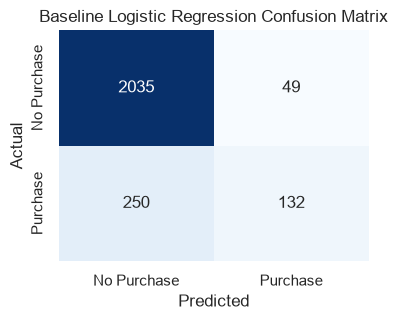

              precision    recall  f1-score   support

           0       0.89      0.98      0.93      2084
           1       0.73      0.35      0.47       382

    accuracy                           0.88      2466
   macro avg       0.81      0.66      0.70      2466
weighted avg       0.87      0.88      0.86      2466

{'model': 'Baseline Logistic Regression', 'accuracy': 0.8787510137875101, 'precision': 0.7292817679558011, 'recall': 0.34554973821989526, 'f1': 0.4689165186500888}


In [67]:
# TODO: Evaluate baseline model using evaluate_predictions.
# TODO: Show confusion matrix.
# TODO: Print classification_report.
evaluation_results = evaluate_predictions(y_test, y_pred_baseline, "Baseline Logistic Regression")
show_confusion_matrix(y_test, y_pred_baseline, "Baseline Logistic Regression Confusion Matrix")
print(classification_report(y_test, y_pred_baseline, zero_division=0))
print(evaluation_results)
results.append(evaluation_results)

## 9. Threshold Tuning

Logistic regression gives probabilities:

\[
P(y=1|x)
\]

The default threshold is usually:

\[
\text{predict purchase if } P(y=1|x) \geq 0.5
\]

But in business problems, we may change the threshold depending on whether we care more about precision or recall.

Try thresholds:

```python
[0.20, 0.30, 0.40, 0.50, 0.60]
```

Threshold: 0.2
              precision    recall  f1-score   support

           0       0.94      0.90      0.92      2084
           1       0.55      0.67      0.60       382

    accuracy                           0.86      2466
   macro avg       0.74      0.78      0.76      2466
weighted avg       0.88      0.86      0.87      2466



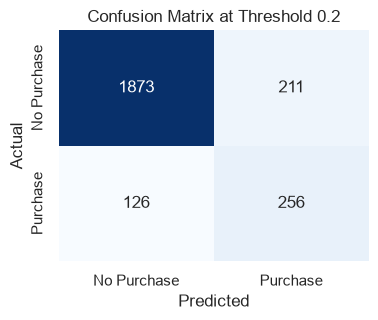

Threshold: 0.3
              precision    recall  f1-score   support

           0       0.92      0.96      0.94      2084
           1       0.69      0.53      0.60       382

    accuracy                           0.89      2466
   macro avg       0.80      0.74      0.77      2466
weighted avg       0.88      0.89      0.88      2466



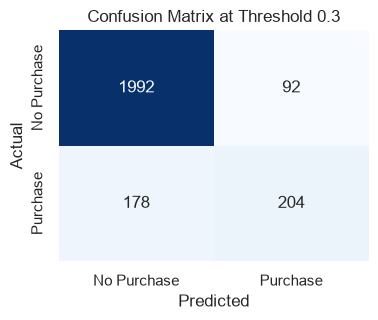

Threshold: 0.4
              precision    recall  f1-score   support

           0       0.90      0.97      0.93      2084
           1       0.71      0.43      0.54       382

    accuracy                           0.89      2466
   macro avg       0.81      0.70      0.74      2466
weighted avg       0.87      0.89      0.87      2466



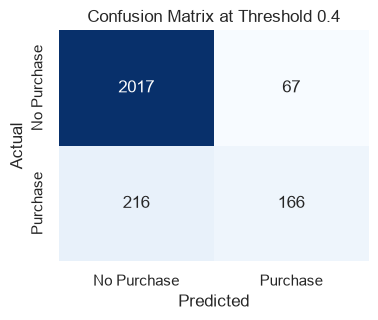

Threshold: 0.5
              precision    recall  f1-score   support

           0       0.89      0.98      0.93      2084
           1       0.73      0.35      0.47       382

    accuracy                           0.88      2466
   macro avg       0.81      0.66      0.70      2466
weighted avg       0.87      0.88      0.86      2466



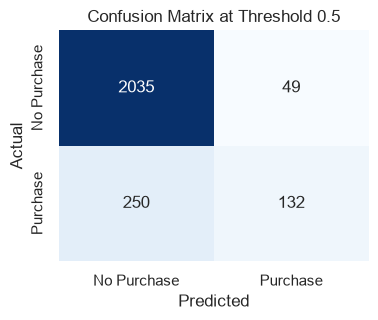

Threshold: 0.6
              precision    recall  f1-score   support

           0       0.88      0.99      0.93      2084
           1       0.78      0.29      0.42       382

    accuracy                           0.88      2466
   macro avg       0.83      0.64      0.68      2466
weighted avg       0.87      0.88      0.85      2466



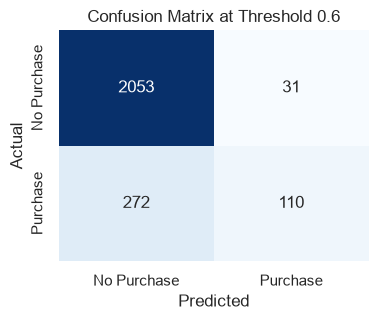

,model,accuracy,precision,recall,f1
0,Threshold 0.2,0.863341,0.548180,0.670157,0.603062
1,Threshold 0.3,0.890511,0.689189,0.534031,0.601770
2,Threshold 0.4,0.885239,0.712446,0.434555,0.539837
3,Threshold 0.5,0.878751,0.729282,0.345550,0.468917
4,Threshold 0.6,0.877129,0.780142,0.287958,0.420650


In [68]:
thresholds = [0.20, 0.30, 0.40, 0.50, 0.60]

# Get probabilities for positive class
y_probs = baseline_model.predict_proba(X_test)[:, 1]

# Store results for all thresholds
threshold_results = []

for threshold in thresholds:
    # Convert probabilities to class predictions
    y_pred_threshold = (y_probs >= threshold).astype(int)

    # Calculate metrics
    evaluation_results = evaluate_predictions(
        y_test,
        y_pred_threshold,
        f"Threshold {threshold}"
    )

    threshold_results.append(evaluation_results)

    print(f"Threshold: {threshold}")

    print(
        classification_report(
            y_test,
            y_pred_threshold,
            zero_division=0
        )
    )

    show_confusion_matrix(
        y_test,
        y_pred_threshold,
        f"Confusion Matrix at Threshold {threshold}"
    )

# Create comparison table
threshold_comparison = pd.DataFrame(threshold_results)

threshold_comparison

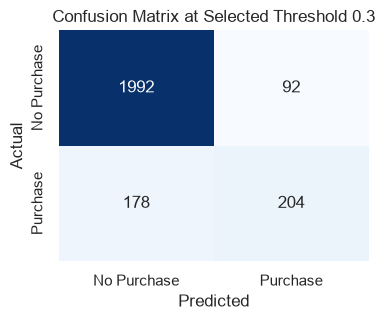

{'model': 'Selected Threshold 0.3', 'accuracy': 0.8905109489051095, 'precision': 0.6891891891891891, 'recall': 0.5340314136125655, 'f1': 0.6017699115044248}


In [69]:
# TODO: Choose one threshold based on your business reasoning.
# Store it in selected_threshold.
# Example: selected_threshold = 0.30


# TODO: Create y_pred_threshold using selected_threshold.
# TODO: Evaluate and append result to results.
# TODO: Show confusion matrix.
selected_threshold = 0.30

# Create predictions using selected threshold
y_pred_threshold = (y_probs >= selected_threshold).astype(int)

# Evaluate predictions
threshold_evaluation = evaluate_predictions(
    y_test,
    y_pred_threshold,
    f"Selected Threshold {selected_threshold}"
)

# Append result to results
results.append(threshold_evaluation)

# Show confusion matrix
show_confusion_matrix(
    y_test,
    y_pred_threshold,
    f"Confusion Matrix at Selected Threshold {selected_threshold}"
)
print(threshold_evaluation)


### Question 3

What happens to precision and recall when you reduce the threshold?

Why does this happen?

Write your answer here:

-

## 10. Class-Weighted Logistic Regression

Train logistic regression with:

```python
class_weight="balanced"
```

This gives more importance to the minority class during training.

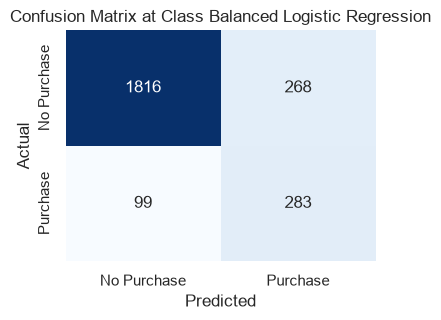

{'model': 'Class Balanced Logistic Regression', 'accuracy': 0.85117599351176, 'precision': 0.5136116152450091, 'recall': 0.7408376963350786, 'f1': 0.6066452304394426}


In [70]:
weighted_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ))
])

weighted_model.fit(X_train, y_train)
y_pred_weighted = weighted_model.predict(X_test)
# Evaluate predictions
evaluation = evaluate_predictions(
    y_test,
    y_pred_weighted,
    f"Class Balanced Logistic Regression"
)

# Append result to results
results.append(evaluation)

# Show confusion matrix
show_confusion_matrix(
    y_test,
    y_pred_weighted,
    f"Confusion Matrix at Class Balanced Logistic Regression"
)
# TODO: Fit weighted_model on X_train and y_train.
# TODO: Predict on X_test and store predictions in y_pred_weighted.
# TODO: Evaluate and append result to results.
# TODO: Show confusion matrix.
print(evaluation)


### Question 4

How did `class_weight="balanced"` change recall and precision compared to the baseline model?

Write your answer here:

- Precision decreased siginificantlly while, recall improved

## 11. SMOTE + Logistic Regression

SMOTE creates synthetic minority-class examples.

Important rule:

> Apply SMOTE only on the training data, never on the test data.

For this assignment, first transform the train and test data using the preprocessor, then apply SMOTE only on the transformed training data.

In [71]:
# TODO: Fit the preprocessor on the training features.
# TODO: Use the fitted preprocessor to transform both training and test features.
#
# Hint:
# - The training set should be used to learn scaling and encoding rules.
# - The test set should only be transformed using those already-learned rules.
# - You will need one processed training feature matrix and one processed test feature matrix.
preprocessed_X_train = preprocessor.fit_transform(X_train)
preprocessed_X_test = preprocessor.transform(X_test)


In [72]:
# TODO: Apply SMOTE only on the processed training data and y_train.
#
# Hint:
# - Create a SMOTE object with RANDOM_STATE.
# - Use the SMOTE resampling method on training data only.
# - Store the resampled features and resampled target separately.
# - Do not apply SMOTE on the test data.

smote = SMOTE(random_state=RANDOM_STATE)

X_train_resampled, y_train_resampled = smote.fit_resample(
    preprocessed_X_train,
    y_train
)

In [73]:
# Train Logistic Regression on SMOTE data
smote_model = LogisticRegression(
    max_iter=1000,
    random_state=RANDOM_STATE
)

smote_model.fit(X_train_resampled, y_train_resampled)

# Predict on untouched processed test data
y_pred_smote = smote_model.predict(preprocessed_X_test)

# Evaluate
smote_results = evaluate_predictions(
    y_test,
    y_pred_smote,
    "Logistic Regression + SMOTE"
)

# Append to results
results.append(smote_results)

# Show confusion matrix
print(smote_results)
print(classification_report(y_test, y_pred_smote, zero_division=0))

{'model': 'Logistic Regression + SMOTE', 'accuracy': 0.8434712084347121, 'precision': 0.496551724137931, 'recall': 0.7539267015706806, 'f1': 0.5987525987525988}
              precision    recall  f1-score   support

           0       0.95      0.86      0.90      2084
           1       0.50      0.75      0.60       382

    accuracy                           0.84      2466
   macro avg       0.72      0.81      0.75      2466
weighted avg       0.88      0.84      0.86      2466



### Question 5

Why should SMOTE be applied only on the training data?

Write your answer here:

- As synthetic data is created, we dont relaly need it in test, only in training

## 12. Final Comparison

Create a final comparison table for all methods:

1. Baseline Logistic Regression
2. Threshold-Tuned Logistic Regression
3. Class-Weighted Logistic Regression
4. SMOTE + Logistic Regression

In [75]:
# TODO: Convert results into a DataFrame and sort/format it clearly.
comparison_df = pd.DataFrame(results)

comparison_df

,model,accuracy,precision,recall,f1
0,Baseline Logistic Regression,0.878751,0.729282,0.345550,0.468917
1,Selected Threshold 0.3,0.890511,0.689189,0.534031,0.601770
2,Class Balanced Logistic Regression,0.851176,0.513612,0.740838,0.606645
3,Logistic Regression + SMOTE,0.843471,0.496552,0.753927,0.598753


## 13. Business Decision Questions

Answer these briefly.

### Question 6

If discount cost is high and the company wants to avoid showing offers to too many non-buyers, should it prioritize precision or recall?

Answer:

- It should prioritize precison.

### Question 7

If missing a potential buyer is very costly, should the company prioritize precision or recall?

Answer:

- It should prioritize recall

### Question 8

Which model/method would you recommend for this business problem?

Mention:

- The model/method you selected
- The metric you prioritized
- Why this decision makes business sense

Answer:

- I would select the threshold 0.3 model as it strike a nice balance between precision and recall while also giving a decent accuracy, so that not many potential buyers are missed while also not spending much on marketing offers

## Submission Checklist

Submit your completed notebook with:

- All code cells executed
- Final comparison table
- Confusion matrices for each method
- Answers to all business questions
- A short final recommendation